In [36]:
%reload_ext autoreload
%autoreload 2

from comet_ml import Experiment
import h5py
import matplotlib.pyplot as plt
import numpy as np
import argparse


import importlib
import random
import os
from algorithms.server.server import Server
from algorithms.trainmodel.models import *
from utils.plot_utils import *
import torch
torch.manual_seed(0)

def main(experiment, dataset, algorithm, model, batch_size, learning_rate, alpha, eta, L, rho, num_glob_iters,
         local_epochs, optimizer, numedges, times, commet, gpu):

    device = torch.device("cuda:{}".format(gpu) if torch.cuda.is_available() and gpu != -1 else "cpu")

    for i in range(times):
        print("---------------Running time:------------",i)

        # Generate model
        if(model == "mclr"):
            if(dataset == "human_activity"):
                model = Mclr_Logistic(561,6).to(device), model
            else:
                model = Mclr_Logistic().to(device), model

        if(model == "linear_regression"):
            model = Linear_Regression(40,1).to(device), model

        if model == "logistic_regression":
            model = Logistic_Regression(300).to(device), model
        
        if model == "MLP" and dataset == "a9a":
            model = DNN( input_dim = 123, output_dim = 2).to(device), model
        if model == "MLP" and dataset == "human_activity":
            model = DNN( input_dim = 561, mid_dim = 561, output_dim = 6).to(device), model
        if model == "MLP" and dataset == "w8a":
            model = DNN( input_dim = 300, output_dim = 2).to(device), model
        if model == "MLP" and dataset == "Mnist":
            model = DNN().to(device), model
        if model == 'CNN':
            model = Net().to(device), model
        # select algorithm
        if(commet):
            experiment.set_name(dataset + "_" + algorithm + "_" + model[1] + "_" + str(batch_size) + "b_" + str(learning_rate) + "lr_" + str(alpha) + "al_" + str(eta) + "eta_" + str(L) + "L_" + str(rho) + "p_" +  str(num_glob_iters) + "ge_"+ str(local_epochs) + "le_"+ str(numedges) +"u")
        server = Server(experiment, device, dataset, algorithm, model, batch_size, learning_rate, alpha, eta,  L, num_glob_iters, local_epochs, optimizer, numedges, i)
        
        server.train()
        server.test()


In [52]:
sophia_params = {
    "dataset": "human_activity",
    "algorithm": "Sophia",
    "model": "MLP",
    "batch_size": 64,
    "learning_rate": 0.001,
    "alpha": (0.90, 0.95),
    "eta": 1.0 * 20,
    "L": 0.001,
    "rho": 20,
    "num_glob_iters": 2 * 41,
    "local_epochs": 1,
    "optimizer": "Sophia",
    "numedges": 32,
    "times": 1,
    "commet": False,
    "gpu": 0
}



DONE_params = {
    "dataset": "human_activity",
    "algorithm": "DONE",
    "model": "MLP",
    "batch_size": 64,
    "learning_rate": 0.001,
    "alpha": 0.003,
    "eta": 0.1,
    "L": 1e-5,
    "rho": 0.001,
    "num_glob_iters": 41,
    "local_epochs": 10,
    "optimizer": "DONE",
    "numedges": 20,
    "times": 1,
    "commet": False,
    "gpu": 0
}

GD_params = {
    "dataset": "human_activity",
    "algorithm": "GD",
    "model": "MLP",
    "batch_size": 64,
    "learning_rate": 0.01,
    "alpha": 0.03,
    "eta": 20.0,
    "L": 1e-3,
    "rho": 0.01,
    "num_glob_iters": 2 * 41,
    "local_epochs": 1,
    "optimizer": "DONE",
    "numedges": 30,
    "times": 1,
    "commet": False,
    "gpu": 0
}

'''
Newton_params = {
    "dataset": "Mnist",
    "algorithm": "Newton",
    "model": "MLP",
    "batch_size": 0,
    "learning_rate": 1,
    "alpha": 0.03,
    "eta": 1.0,
    "L": 1e-3,
    "rho": 0.01,
    "num_glob_iters": 500,
    "local_epochs": 40,
    "optimizer": "Newton",
    "numedges": 30,
    "times": 1,
    "commet": True,
    "gpu": 0
}

'''

'\nNewton_params = {\n    "dataset": "Mnist",\n    "algorithm": "Newton",\n    "model": "MLP",\n    "batch_size": 0,\n    "learning_rate": 1,\n    "alpha": 0.03,\n    "eta": 1.0,\n    "L": 1e-3,\n    "rho": 0.01,\n    "num_glob_iters": 500,\n    "local_epochs": 40,\n    "optimizer": "Newton",\n    "numedges": 30,\n    "times": 1,\n    "commet": True,\n    "gpu": 0\n}\n\n'

In [53]:
experiment = Experiment(
        api_key="q24VqIVkFNEOugLA3T0YFFFvE",
        project_name="sophia",
        workspace="abdulmomen96",
    )
main(experiment, **GD_params)
experiment.end()    


COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/abdulmomen96/sophia/53eafebb17474fe7af2d0a097562e15e



---------------Running time:------------ 0
Number of edges / total edges: 30  /  30
-------------Round number:  0  -------------
Average Test Accuracy          :  0.08668730650154799
Average Global Trainning Accuracy:  0.08917692806221646
Average Global Trainning Loss    :  1.8344141131318858
-------------Round number:  1  -------------
Average Test Accuracy          :  0.16369969040247678
Average Global Trainning Accuracy:  0.1644847699287103
Average Global Trainning Loss    :  1.8073471929682436
-------------Round number:  2  -------------
Average Test Accuracy          :  0.16408668730650156
Average Global Trainning Accuracy:  0.16746597537265068
Average Global Trainning Loss    :  1.7841600676441995
-------------Round number:  3  -------------
Average Test Accuracy          :  0.15905572755417957
Average Global Trainning Accuracy:  0.1594296824368114
Average Global Trainning Loss    :  1.763975666315619
-------------Round number:  4  -------------
Average Test Accuracy          :  

-------------Round number:  39  -------------
Average Test Accuracy          :  0.6482198142414861
Average Global Trainning Accuracy:  0.6482177576150356
Average Global Trainning Loss    :  1.4110382574530136
-------------Round number:  40  -------------
Average Test Accuracy          :  0.6509287925696594
Average Global Trainning Accuracy:  0.6556059624108879
Average Global Trainning Loss    :  1.403206264176928
-------------Round number:  41  -------------
Average Test Accuracy          :  0.656733746130031
Average Global Trainning Accuracy:  0.6615683732987686
Average Global Trainning Loss    :  1.3954319912508102
-------------Round number:  42  -------------
Average Test Accuracy          :  0.6602167182662538
Average Global Trainning Accuracy:  0.6661049902786779
Average Global Trainning Loss    :  1.387715944993519
-------------Round number:  43  -------------
Average Test Accuracy          :  0.6652476780185759
Average Global Trainning Accuracy:  0.6711600777705768
Average Globa

-------------Round number:  79  -------------
Average Test Accuracy          :  0.7573529411764706
Average Global Trainning Accuracy:  0.7583927414128322
Average Global Trainning Loss    :  1.1498811416477641
-------------Round number:  80  -------------
Average Test Accuracy          :  0.7581269349845201
Average Global Trainning Accuracy:  0.7600777705767985
Average Global Trainning Loss    :  1.144772004617628
-------------Round number:  81  -------------
Average Test Accuracy          :  0.7589009287925697
Average Global Trainning Accuracy:  0.7607258587167854
Average Global Trainning Loss    :  1.139725018227479


COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     url                   : https://www.comet.com/abdulmomen96/sophia/53eafebb17474fe7af2d0a097562e15e
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     glob_acc [82]   : (0.08668730650154799, 0.7589009287925697)
COMET INFO:     loss [246]      : (1.086465835571289, 1.8564082384109497)
COMET INFO:     train_acc [82]  : (0.08917692806221646, 0.7607258587167854)
COMET INFO:     train_loss [82] : (1.139725018227479, 1.8344141131318858)
COMET INFO:   Uploads:
COMET INFO:     conda-environment-definition : 1
COMET INFO:     conda-info                   : 1
COMET INFO:     conda-specification          : 1
COMET INFO:     environment details          : 1
COMET INFO:     filena

In [ ]:
'''
Human Activity
Sophia
-------------Round number:  40  -------------
Average Test Accuracy          :  0.8502321981424149
Average Global Trainning Accuracy:  0.8495139338950097
Average Global Trainning Loss    :  1.0823885845349968
Clipping rate = 0.576000928907216

"learning_rate": 0.0001,
    "alpha": (0.9, 0.95),
    "eta": 1.0 * 50,
    "L": 0.001,
    "rho": 20,


GD
-------------Round number:  40  -------------
Average Global Accuracy          :  0.20936532507739938
Average Global Trainning Accuracy:  0.20764744005184704
Average Global Trainning Loss    :  1.7220779072828905


'''

'''
MNIST MLP
Sophia 
-------------Round number:  39  -------------
Average Global Accuracy          :  0.8934867045115028
Average Global Trainning Accuracy:  0.8913894080996885
Average Global Trainning Loss    :  0.3557637022975078

GD
-------------Round number:  40  -------------
Average Global Accuracy          :  0.5679713175978488
Average Global Trainning Accuracy:  0.5671775700934579
Average Global Trainning Loss    :  1.9333872663551401

'''

In [54]:
from utils.plot_utils import get_training_data_value, simple_read_data

In [55]:


rs_train_acc_sop, rs_train_loss_sop, rs_glob_acc_sop = simple_read_data("human_activity_Sophia_0.001_(0.9, 0.95)_20.0_0.001_32u_64b_1_0")
rs_train_acc_done, rs_train_loss_done, rs_glob_acc_done = simple_read_data("human_activity_DONE_0.001_0.003_0.1_1e-05_20u_64b_10_0")
rs_train_acc_gd, rs_train_loss_gd, rs_glob_acc_gd = simple_read_data("human_activity_GD_0.01_0.03_20.0_0.001_30u_64b_1_0")

human_activity_Sophia_0.001_(0.9, 0.95)_20.0_0.001_32u_64b_1_0
human_activity_DONE_0.001_0.003_0.1_1e-05_20u_64b_10_0
human_activity_GD_0.01_0.03_20.0_0.001_30u_64b_1_0


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


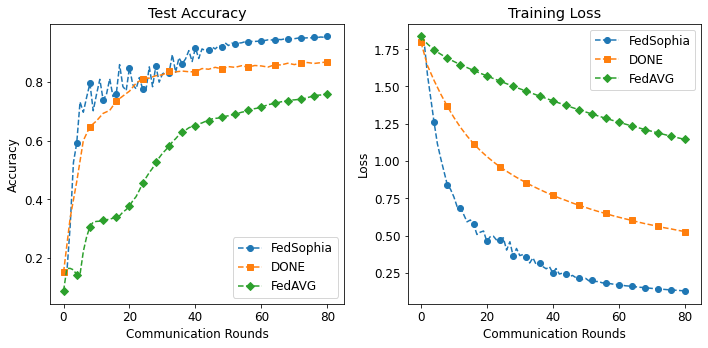

In [58]:

import matplotlib.pyplot as plt
import numpy as np

# Create a figure with two subplots
plt.figure(figsize=(10, 5))
x = np.arange(0, 82)
x_DONE = np.arange(0, 2 * 41, 2)
xlim = 41

# Subplot 1: Training Accuracy
plt.subplot(1, 2, 1)
plt.plot(x, rs_glob_acc_sop, label='FedSophia', linestyle='--', marker='o', markevery=4)
plt.plot(x_DONE, rs_glob_acc_done, label='DONE', linestyle='--', marker='s', markevery=4)
plt.plot(x, rs_glob_acc_gd, label='FedAVG', linestyle='--', marker='D', markevery=4)

plt.title('Test Accuracy')
plt.xlabel('Communication Rounds')
plt.ylabel('Accuracy')
plt.legend()

# Subplot 2: Training Loss
plt.subplot(1, 2, 2)
plt.plot(x, rs_train_loss_sop, label='FedSophia', linestyle='--', marker='o', markevery=4)
plt.plot(x_DONE, rs_train_loss_done, label='DONE', linestyle='--', marker='s', markevery=4)
plt.plot(x, rs_train_loss_gd, label='FedAVG', linestyle='--', marker='D', markevery=4)

plt.title('Training Loss')
plt.xlabel('Communication Rounds')
plt.ylabel('Loss')
plt.legend()

plt.savefig('human_activity.eps', format='eps')

plt.tight_layout()
plt.show()


In [44]:
#1.027

np.mean(np.equal(np.ones((20, 1), np.float32), 0.0))

0.0

In [34]:
x_DONE


array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32,
       34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60, 62, 64, 66,
       68, 70, 72, 74, 76, 78, 80])